In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Display options
pd.set_option('display.max_columns', None)


# Load data

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

In [3]:
# Inspect the first few rows
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Inspect the first few rows
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
# Count missing values per column
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
train.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


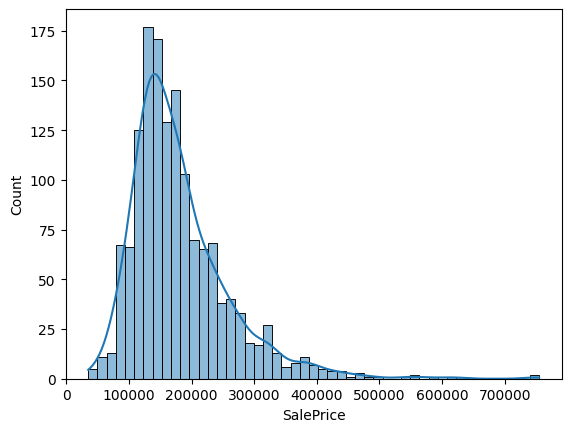

In [7]:
sns.histplot(train['SalePrice'], kde=True)
plt.show()


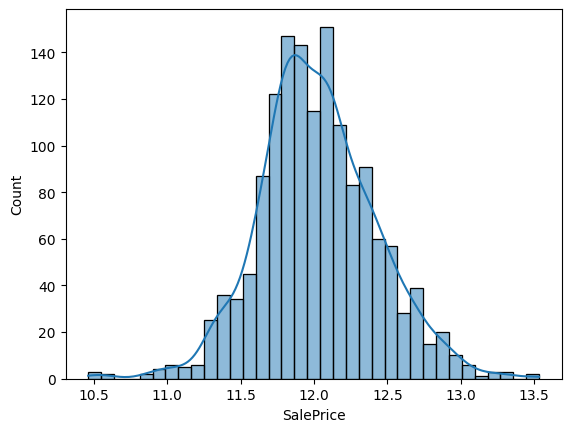

In [8]:
train['SalePrice'] = np.log1p(train['SalePrice'])
y_train = train['SalePrice']
sns.histplot(train['SalePrice'], kde=True)
plt.show()

In [9]:
corr = train.select_dtypes(include=['int64', 'float64']).corr()['SalePrice'].sort_values(ascending=False).head(11)
print(corr)

SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
Name: SalePrice, dtype: float64


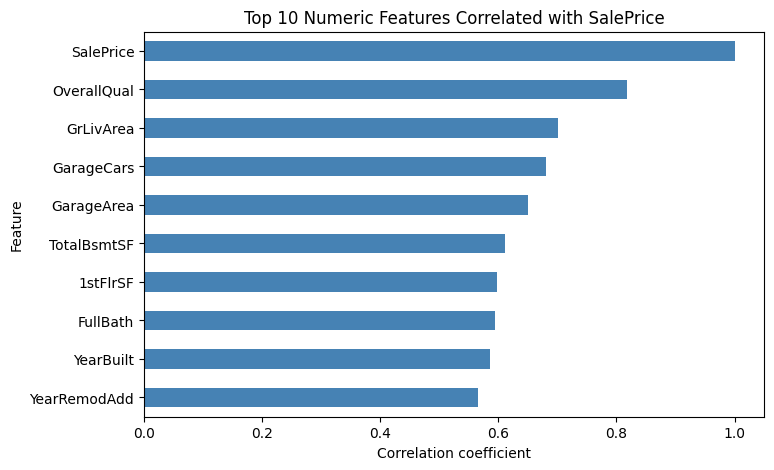

In [10]:
plt.figure(figsize=(8, 5))
corr.head(10).iloc[::-1].plot(kind='barh', color='steelblue')
plt.title('Top 10 Numeric Features Correlated with SalePrice')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.show()


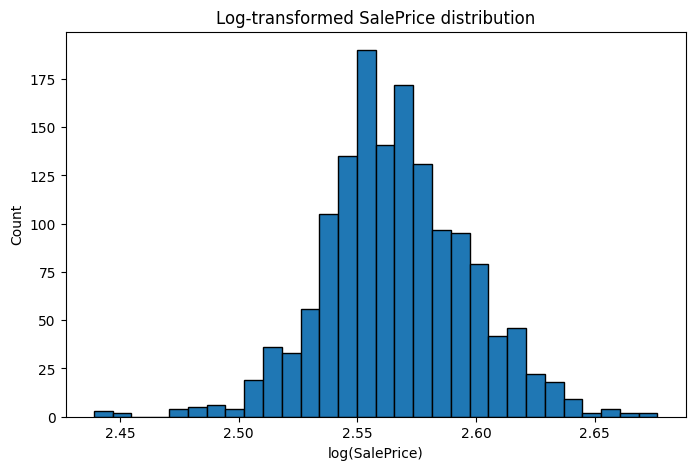

In [11]:

train['SalePrice_log'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice_log'], bins=30, edgecolor='black')
plt.title("Log-transformed SalePrice distribution")
plt.xlabel("log(SalePrice)")
plt.ylabel("Count")
plt.show()


In [12]:
# Identify categorical columns
cat_features = train.select_dtypes(include=['object']).columns.tolist()
cat_features[:20], len(cat_features)


(['MSZoning',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'ExterQual',
  'ExterCond'],
 43)

In [13]:
# Count unique categories for each categorical variable
cat_uniques = train[cat_features].nunique().sort_values()

cat_uniques.head(15), cat_uniques.tail(15)


(Street          2
 Alley           2
 CentralAir      2
 Utilities       2
 MasVnrType      3
 LandSlope       3
 PoolQC          3
 PavedDrive      3
 GarageFinish    3
 BsmtQual        4
 ExterQual       4
 KitchenQual     4
 BsmtCond        4
 BsmtExposure    4
 Fence           4
 dtype: int64,
 RoofStyle         6
 GarageType        6
 Foundation        6
 Heating           6
 BsmtFinType2      6
 SaleCondition     6
 Functional        7
 RoofMatl          8
 HouseStyle        8
 Condition2        8
 SaleType          9
 Condition1        9
 Exterior1st      15
 Exterior2nd      16
 Neighborhood     25
 dtype: int64)

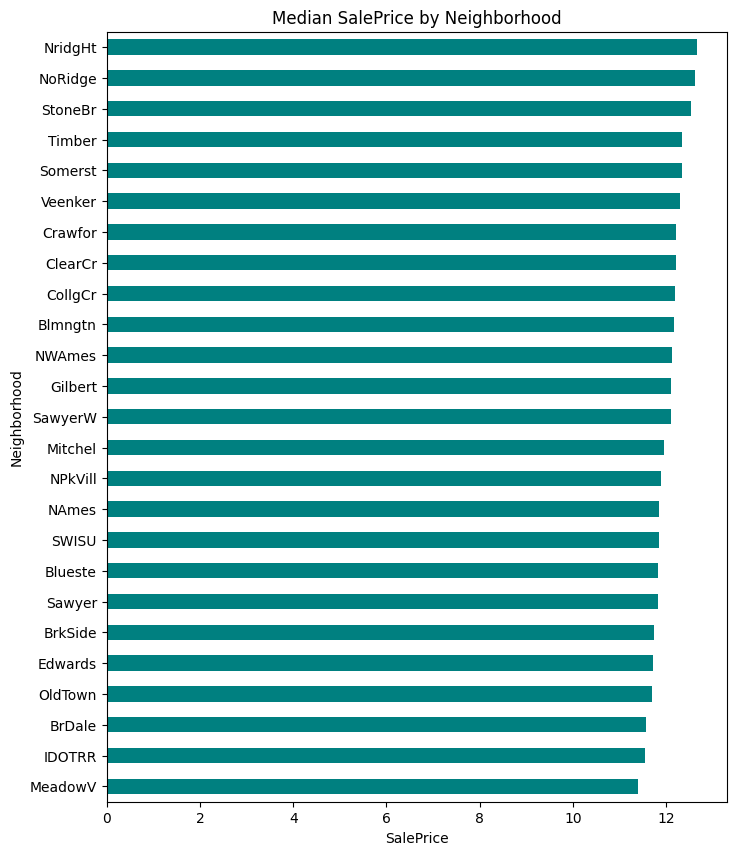

In [14]:
train.groupby("Neighborhood")["SalePrice"].median().sort_values().plot(
    kind="barh", figsize=(8, 10), color="teal"
)

plt.title("Median SalePrice by Neighborhood")
plt.xlabel("SalePrice")
plt.ylabel("Neighborhood")
plt.show()


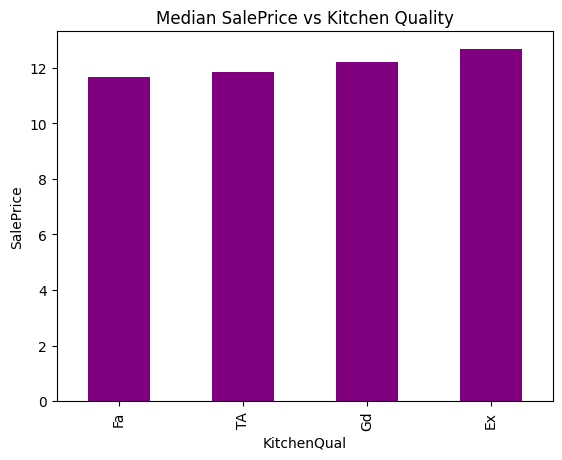

In [15]:
train.groupby("KitchenQual")["SalePrice"].median().sort_values().plot(
    kind="bar", color="purple"
)

plt.title("Median SalePrice vs Kitchen Quality")
plt.xlabel("KitchenQual")
plt.ylabel("SalePrice")
plt.show()


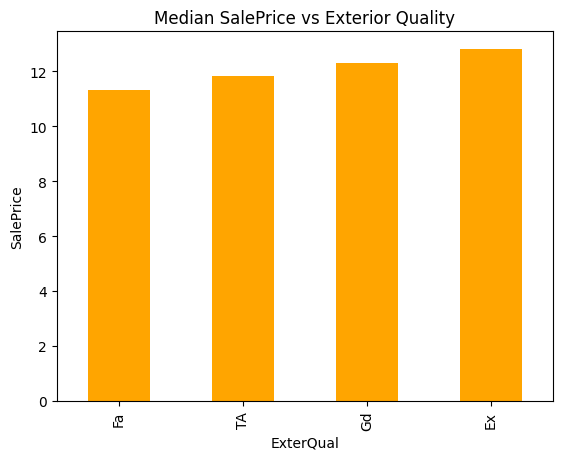

In [16]:
train.groupby("ExterQual")["SalePrice"].median().sort_values().plot(
    kind="bar", color="orange"
)

plt.title("Median SalePrice vs Exterior Quality")
plt.xlabel("ExterQual")
plt.ylabel("SalePrice")
plt.show()


In [17]:
no_feature_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in no_feature_cols:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")


In [18]:
zero_fill_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath'
]

for col in zero_fill_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)


In [19]:
mode_fill_cols = ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd']

for col in mode_fill_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(train[col].mode()[0])


In [20]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)


In [21]:
train.isnull().sum().sort_values(ascending=False).head(10)


Id              0
GarageCars      0
GarageYrBlt     0
GarageType      0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
dtype: int64

In [22]:
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

train.isnull().sum().sum(), test.isnull().sum().sum()


(0, 0)

In [23]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
len(cat_cols), cat_cols[:10]


(43,
 ['MSZoning',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1'])

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


In [26]:
# Reidentify categorical and numeric columns after cleaning
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in train.columns if c not in cat_cols and c not in ['SalePrice', 'SalePrice_log']]


In [27]:
X = train.drop(['SalePrice', 'SalePrice_log'], axis=1)
y = train['SalePrice_log']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


In [30]:
preprocessor

ColumnTransformer(transformers=[('cat',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'MasVnrType', 'ExterQual',
                                  'ExterCond',...
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
                                  'FullBath', 'HalfBath', 'BedroomAbvGr',
                                  'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
                                  'GarageYrBlt', 'GarageCars', 'GarageArea',
                                  'WoodDeckSF', 'OpenPorchSF', ...])])

# First Model: Decision Tree

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

dt_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)
preds = dt_model.predict(X_val)
rmse_dt = mean_squared_error(y_val, preds, squared=False)
rmse_dt


0.0151834813262894

# Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_val)
rmse_rf = mean_squared_error(y_val, preds, squared=False)
rmse_rf


0.01153955026113338

# XGBoost

In [33]:
import xgboost as xgb

xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_val)
rmse_xgb = mean_squared_error(y_val, preds, squared=False)
rmse_xgb


0.010499856949607995

# comparing results

In [34]:
rmse_dt, rmse_rf, rmse_xgb


(0.0151834813262894, 0.01153955026113338, 0.010499856949607995)

# Optimizing XgBoost model

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


In [36]:
import xgboost as xgb

xgb_base = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])


In [37]:
param_grid = {
    "model__n_estimators": [100, 150, 200, 250, 300, 500, 800],
    "model__learning_rate": [1.0, 0.1, 0.01, 0.03, 0.05],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}


In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=25,                   # 25 random combinations
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


In [39]:
xgb_random_search.fit(X_train, y_train)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               ['MSZoning',
                                                                                'Street',
                                                                                'Alley',
                                                                                'LotShape',
                                                                                'LandContour',
                                                                                'Utilities',
                                                                                'LotConfig',
                                                                                'LandSlope',
                                                                                'Neighborhood',
                                                                                'Condition1',
                                                                                'Condition2',
                                                                                'BldgType',
                                                                                'HouseStyle',
                                                                                'RoofStyle',
                                                                                'RoofMatl',
                                                                                '...
                                                           num_parallel_tree=None, ...))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [1.0, 0.1, 0.01,
                                                                 0.03, 0.05],
                                        'model__max_depth': [3, 4, 5],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 150, 200,
                                                                250, 300, 500,
                                                                800],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [40]:
print("Best RMSE:", -xgb_random_search.best_score_)
print("Best params:", xgb_random_search.best_params_)


Best RMSE: 0.009685200992524765
Best params: {'model__subsample': 0.7, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}


In [42]:
best_params = xgb_random_search.best_params_
print(best_params)
xgb_best = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        **{k.replace("model__", ""): v for k, v in best_params.items()}
    ))
])

xgb_best.fit(X_train, y_train)

preds = xgb_best.predict(X_val)
rmse_best = mean_squared_error(y_val, preds, squared=False)
rmse_best


{'model__subsample': 0.7, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}


0.010396095574945415

# Saving the model

In [43]:
import pickle

with open("../model/model_xgb_optimized.pkl", "wb") as f:
    pickle.dump(xgb_best, f)
